In [1]:
import pandas as pd
df = pd.read_csv("data\\processed\\merged_imb_dataset2.csv")
df.sort_index()
df = pd.DataFrame(df).ffill()
df_u = df.copy()
before = len(df_u)
df_u = df_u.drop_duplicates(subset=["Date"])
df_u = df_u.drop(columns="Date",axis = 1)
after = len(df_u)
import logging
logging.basicConfig(filename="log/ingestion.log",level=logging.INFO,format = "%(asctime)s - %(name)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)
if before > after:
    logger.info(f"Deduplication on copy|{before - after} rows removed")

from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split,cross_validate,TimeSeriesSplit
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
df_u["return_pct"] = df_u["return_pct"].shift(-1)
df_u = df_u.dropna(subset=["return_pct"])
X = df_u.copy()
X = X.drop(["return_pct","return_log"],axis = 1)
split_point = int(len(df) * 0.7)

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]

Y_train = df_u["return_pct"].iloc[:split_point]
Y_test = df_u["return_pct"].iloc[split_point:]

import numpy as np
# --- Baseline 1: always guess "no change" (0% return) ---
baseline_zero = np.zeros(len(Y_test))

# --- Baseline 2: always guess the average return seen in training data ---
baseline_mean = np.full(len(Y_test), Y_train.mean())

# --- Baseline 3: guess "tomorrow will do what happened last" ---
# take the actual returns, shift them down by one row, so today's guess = yesterday's real value
baseline_persistence = Y_test.shift(1)
baseline_persistence.iloc[0] = Y_train.iloc[-1]  # first row has no "yesterday" in the test set, borrow last train value

# --- Score all three the same way you'll score real models ---
for name, prediction in [
    ("Always 0", baseline_zero),
    ("Always mean", baseline_mean),
    ("Copy last value", baseline_persistence),
]:
    mae = mean_absolute_error(Y_test, prediction)
    r2 = r2_score(Y_test, prediction)
    print(f"{name:16s} | MAE: {mae:.6f} | R2: {r2:.6f}")

imputable = [i for i in X_train.columns if X_train[i].isnull().any()]
column1 = ColumnTransformer(transformers=[
    ("Impute",SimpleImputer(strategy='median'),imputable)
])
if len(imputable) > 0:
    pipe1 = Pipeline(steps = [
        ("Column1",column1),
        ("model",LinearRegression())
    ])
else:
    pipe1 = Pipeline(steps = [
        ("model",LinearRegression())
        ])

non_imputable = [i for i in X_train.columns if i not in imputable]
column2 = ColumnTransformer(transformers=[
    ("impute_then_scale", Pipeline(steps=[
        ("impute", SimpleImputer(strategy='median')),
        ("scale", StandardScaler())
    ]), imputable),
    ("Scalenonimpt", StandardScaler(copy=True, with_mean=True, with_std=True), non_imputable)
])
pipe2 = Pipeline(steps = [
    ("Column2",column2),
    ("model",LinearRegression())
])


Always 0         | MAE: 0.011985 | R2: -0.001892
Always mean      | MAE: 0.011968 | R2: -0.001186
Copy last value  | MAE: 0.017140 | R2: -0.871054


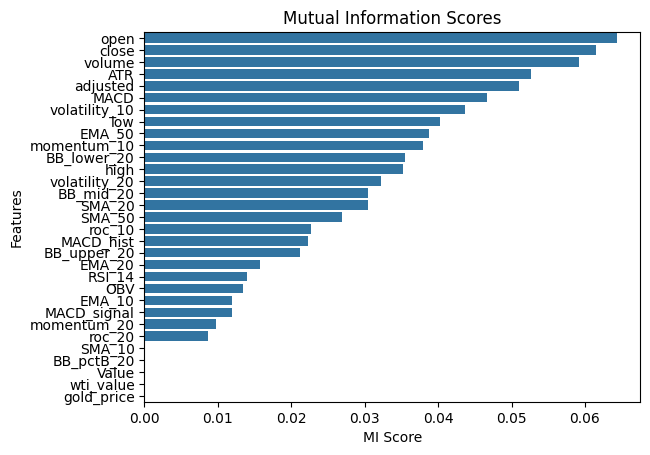

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_regression as mi
X_n = X_train.copy()
mi_scores = mi(X_n,Y_train)
mi_series = pd.Series(mi_scores, index=X_n.columns).sort_values(ascending=False)

plt.figure()
sns.barplot(x=mi_series.values, y=mi_series.index)
plt.title("Mutual Information Scores")
plt.xlabel("MI Score")
plt.ylabel("Features")
plt.show()

In [3]:
X_train2 = X_train.drop(["SMA_10","gold_price","wti_value","Value","BB_pctB_20"],axis = 1)
X_test2 = X_test.drop(["SMA_10","gold_price","wti_value","Value","BB_pctB_20"],axis = 1)

imputable2 = [i for i in X_train2.columns if X_train2[i].isnull().any()]
non_imputable2 = [i for i in X_train2.columns if i not in imputable2]
p = Pipeline(steps=[("Impute",SimpleImputer(strategy="median")),
                    ("scale_imputed",StandardScaler(copy=True,with_mean=True,with_std=True))])
column3 = ColumnTransformer(transformers=[
    ("impute and scale",p,imputable2),
    ("Scale",StandardScaler(copy=True,with_mean=True,with_std=True),non_imputable2),
])
pipe3 = Pipeline(steps=[("Imp_scale",column3),("model",LinearRegression())])


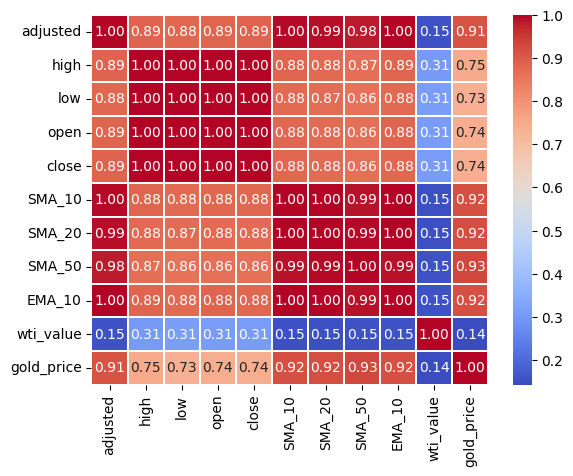

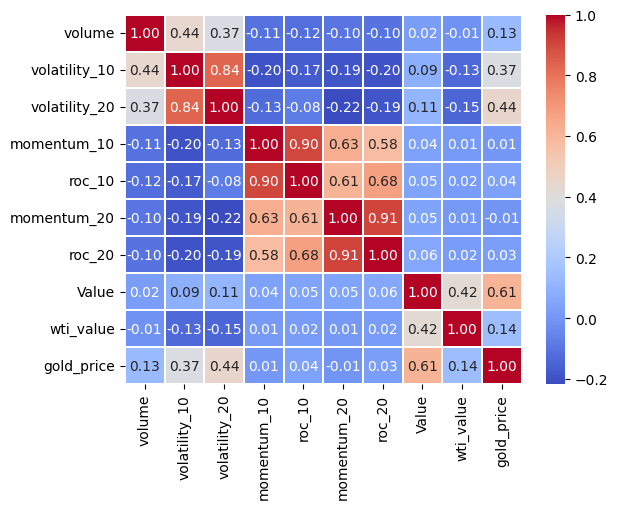

In [4]:
sns.heatmap(data = X[["adjusted","high","low","open","close","SMA_10","SMA_20","SMA_50","EMA_10","wti_value","gold_price"]].corr(),annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.100,cbar=True)
plt.show()
sns.heatmap(data = X[["volume","volatility_10","volatility_20","momentum_10","roc_10","momentum_20","roc_20","Value","wti_value","gold_price"]].corr(),annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.10,cbar=True)
plt.show()

In [5]:
from sklearn.decomposition import PCA

pca_col2 = ["adjusted","high","open","low","close","SMA_20","SMA_50"]
X_train4 =  X_train.drop(["SMA_10","gold_price","wti_value","Value","BB_pctB_20"],axis = 1)
non_pca2 = [i for i in X_train4.columns if i not in pca_col2]
X_test4 =  X_test.drop(["SMA_10","gold_price","wti_value","Value","BB_pctB_20"],axis = 1)
p2 = Pipeline(steps=[
    ("impute",SimpleImputer(strategy="median")),
    ("scale",StandardScaler(with_mean=True,with_std=True,copy=True)),
    ("Pca",PCA(n_components=0.95))])
p3 = Pipeline(steps=[
    ("impute",SimpleImputer(strategy="median")),
    ("scale",StandardScaler(with_mean=True,with_std=True,copy=True))])
column4 = ColumnTransformer(transformers=[
    ("non_pca_process",p3,non_pca2),
    ("pca_process",p2,pca_col2)
])
pipe4 = Pipeline(steps=[("process",column4),("model",LinearRegression())])


Tss = TimeSeriesSplit(n_splits=5,gap=5)
results = cross_validate(estimator = pipe1,cv = Tss,X = X_train,y = Y_train,scoring={"r2" : "r2","mae" : "neg_mean_absolute_error"})
results2 = cross_validate(estimator = pipe2,cv = Tss,X = X_train,y = Y_train,scoring={"r2" : "r2","mae" : "neg_mean_absolute_error"})
results3 = cross_validate(estimator= pipe3,cv = Tss,X = X_train2,y = Y_train,scoring={"r2" : "r2","mae" : "neg_mean_absolute_error"})
results4 = cross_validate(estimator= pipe4,cv = Tss,X = X_train4,y = Y_train,scoring={"r2" : "r2","mae" : "neg_mean_absolute_error"})

print("\nCross validation scores \n")
print("R2 1:", results["test_r2"].mean())
print("MAE 1:", -results["test_mae"].mean())

print("R2 2:", results2["test_r2"].mean())
print("MAE 2:", -results2["test_mae"].mean())

print("R2 3:", results3["test_r2"].mean())
print("MAE 3:", -results3["test_mae"].mean())

print("R2 4:", results4["test_r2"].mean())
print("MAE 4:", -results4["test_mae"].mean())



Cross validation scores 

R2 1: -0.11511013921670687
MAE 1: 0.010501136250717892
R2 2: -0.11511013873774507
MAE 2: 0.010501136249034015
R2 3: -0.10227785808751397
MAE 3: 0.010398832166843033
R2 4: -0.06587642785559034
MAE 4: 0.010161550488586336


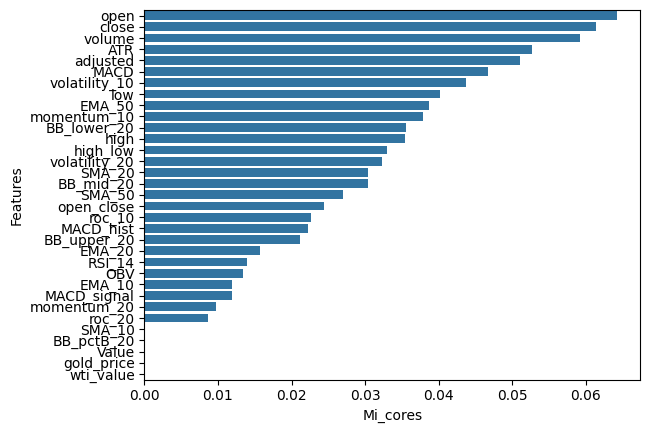

In [6]:
X_new = X_train.copy()
imputer = SimpleImputer(strategy="median")
X_new = pd.DataFrame(imputer.fit_transform(X_new),columns = X_new.columns)
X_new["open_close"] = X_new["open"]/X_new["close"]
X_new["high_low"] = X_new["high"]/X_new["low"]
mi_scores = mi(X_new,Y_train)
mi_score = pd.Series(mi_scores,index = X_new.columns).sort_values(ascending=False)
plt.figure()
sns.barplot(x = mi_score.values,y=mi_score.index)
plt.xlabel("Mi_cores")
plt.ylabel("Features")
plt.show()

In [7]:
pipe1.fit(X_train,Y_train)
pred = pipe1.predict(X_test)
print("MAE 1:-",mean_absolute_error(pred,Y_test))
print("R2 score 1: ",r2_score(pred,Y_test))

pipe2.fit(X_train,Y_train)
pred2 = pipe2.predict(X_test)
print("MAE 2:-",mean_absolute_error(pred2,Y_test))
print("R2 score 2: ",r2_score(pred2,Y_test))

pipe3.fit(X_train2,Y_train)
pred3 = pipe3.predict(X_test)
print("MAE 3:-",mean_absolute_error(pred3,Y_test))
print("R2 scoer 3: ",r2_score(pred3,Y_test))

pipe4.fit(X_train4,Y_train)
pred4 = pipe4.predict(X_test)
print("MAE 4:-",mean_absolute_error(pred4,Y_test))
print("R2 scoer 4: ",r2_score(pred4,Y_test))

MAE 1:- 0.02286283275353403
R2 score 1:  -2.123575754383748
MAE 2:- 0.022862832595632206
R2 score 2:  -2.1235757637501957
MAE 3:- 0.018929390147231728
R2 scoer 3:  -3.2170257349452545
MAE 4:- 0.019316876753929377
R2 scoer 4:  -2.9876697842502247


History of decisions:-
1. I took the raw 3824 by 33 data set i removed date from it split it for 70 % as train 10 percent as validation  split and remaining for test
2. i feed the data to linear regression after just imputation with mean stratergy and it got very high negative r2 score indicating the too much variation in raw stock data and higher mae score than all future pipelines
3. I used standard scalar after imputation with mean and std and then r2 score becore positive and was less than 1 indicating the reduce of variations due to scalling 
4. I then mutual info regression and plot the mi scores the lowest one were MACD and MACD signal and when i removed them it caused the mae increased and r2 decreased i concluded that the variation is reduced due to removing features and may the mae depends on variation it caputurs in case of stock data set but the previous high r2 score in negative and high mae showed that scalling is neccessary as raw variation is too huge 
5. I then implemented PCA on highly collerated features and kept other features as normally scaled like previosuly the features which i selected can be seen in pca_col list and in heat maps and after training i found pca reduced the r2 score even furthur and increased mae score to check wheather my conclusion on output depend on variation amount is right or not i increased the n_componenet from 0.95 to 0.98 and as expected mae decreased a bit and r2 incresed 
6. I also tried using picking only one features out of group of features whose colleration was too high i.e. 1 then the result was still bad i was convinced that variation dominated predictions
7. I then used cross validation and result was same majority time a little difference in mae and r2 score i conluded that it is due to the reason that it takes mean of 5 tests not one raw test 
8. I then took ratios of features with almost same or close mean with the basic instincts like of open and close, high and low and the mi score is these 2 was too huge than expectations but others like ema_10 and ema_20 or sma_10 and sma_20 and for those of volatility and momentum was very poor i for finding wheather the existence of similar features have any impact on each other mi scores i testesby ploting all features with new one and new one by removing thier parents form plot so i find no impact at all then i tested those new features on pipeline2 and result was suprisingly same for both having new features with parent features or only new derived features while their parents dropped from dataframe even more high mae after we added new ratios even if ratios have higher mi score  so i concluded that derived features i concluded that the relation of featuer with target matter less than the variation it provides for model
9. Now biggest changed happen i removed the validation set and make the training set 80 percent and test set rest 20 the findings were shocking that the actually the first raw imputed feeding to pipe1 had low mae score but very huge
r2 negative socre on single test but on cross validationt the mae decreaed and the r2 was negative but very huge or say less (negative numbers are huge if number of digits is low and less of number of digits is high so for this time i guess i should say r2 increaed if it is negative ) and also the mae of scaled one pipe2 was more and the r2 score the variation positive this time was higher of pipe2 well do not get confused in high low due to negative numbers check results above or by running code you are reading and the mae other pipelines was also unexpected so i concluded that not only amount of variation matter also thier might be a chance that previously the models became bias for validation data and got underfitting when we changed the dataset obeservations and used cross validation to feed new patterns and more variations to models they behaved diffently until now my all conclusions were proved wrong but now i am logging all pipelines and thier socores and i choose pipe3 for our predicion model because it reduced unnneccassary features and thier computation requirement provided more variation that old pipe2 and better accuracy that pipe4 (new pipe2) 
10. I choose Linear regression because since observations are low and variation  matters much and entire data is numeric furthur division using random forest and decision tress may give bad outputs and XBboost willl be overkill for this small data set

New observations after changes in code :- 
1. After debugging from claude i shifted the return_pct by -1 and imputes entire data set using ffill and just kept median imputation in case if there were any nan observations left due to thier positions before non nan observations i replaced cv form k fold to timeseries split calculated mi score on base of training set instead of entire data set and now with clear and stable mae and r2 scoers and cv scores i removed unneccassary testing of combinations of differnt features and ratios by observing changed mi scores and resutls 
2. The r2 across the pipelines become stable and mae also became stable and now the cross validation is consistent do not cause sudden changes in output and normal tests are also stable the same outputs in cross validation and normal tests with and without scaling shows that the variation now do not play much impact like it did last time with wrong target and cross validation splits and imputation the main cullprit were the weak patterns in stock market data like the mi scores of features is too low and even of thier ratios is too low and many were highly collerated causing the multicolinear issue which is solved by pca and now since the the difference in the mean and median of all featuers is not too large and all are moderatly right skewed and the result of thier raw and scaled featuers is same i guess i do not need to worry about oultiers all ratio combinations were unsuccessfull.
3. Using claude a base line was established for mae and r2 on three cases first case the return pct is 0 and second case it returned mean of overall returnpct across the 3824 rows and third it returned same returnpct as yesterday shocking part that none of the pipeline of mine could beat the baseline which caused my entire point of view wrong again i first didn't agreed with claude pipeline it beat my pipeline scores but couldn't beat base line either i doubted the base line but the future findings on the signals and how noisy and weak the data was will be explored highly in future  observations
4. So i tried different method again i tried differnt models in desperation i tried taking some columns claude removed back and see the results nothing was improving after it i learned concept of multicollinearilty which as we can see in heat map our features are creating this problem since features are highly collerated and almost represent same informations like majority have same or highl closed mean ,std, min and max and quaters and this was also the reason how i choosed features for pca_col and selecting a random column in group where features represented colleration 1 at heat map i analyse thier means and std and since they were close i could tell that the amount of values may not be too far for these features and as i explored and learned furthur about it all things started connecting dots since the shift in test split caused such huge differnce the moment i changed to mi scores calculation from whole data set to 70 percent training set it changed highly well the data leakage problem existed but the sudden changed in mae scores, cv scores, mi scores, etc. showed that only due to changes in split sizes and when i involved cv the the gaps in accuray and final tests showed huge failures on change in patterns encountered in  test data set and in pipeline 4 when the removing low mi scores and using pca to keep 95 percent variations while reducing featuers set the r2 score reduced as expected the low mi scores feaures may be weak signals but still can provide some signals or say noise but even a pca couldn't solved the high mae score problem showing only keeping useful vairation do not help against sudden regime shift in data which is was the main explanation claude gave which is now proved by all pca, removing low mi scores and taking only one featue in group of highly collerated features still the the encounters of pipelines against test set was highly disappointment. The belive that the test split contain a sudden regime shift and may contain complex patters for model is evaluated by me in below code cell using just y_train decribe and y_test decribe. 

In [8]:
import numpy as np
# ---------------------------------------------------------------
# 1. Columns that carry raw, drifting level information:
#    - OHLC/adjusted: the raw stock price itself, trends over years
#    - SMA/EMA/BB bands: smoothed versions of that same trending price
#    - OBV: a running cumulative sum, grows unbounded over time by construction
#    - Value/wti_value/gold_price: raw treasury yield / oil / gold price levels,
#      these also trend over multi-year periods, same drift problem
# ---------------------------------------------------------------
price_level_cols = [
    "open", "high", "low", "adjusted","close",
    "SMA_10","SMA_20", "SMA_50","EMA_10","EMA_20", "EMA_50",
    "BB_upper_20", "BB_lower_20","OBV",
    "Value", "wti_value", "gold_price","BB_mid_20"
]

drop_cols = [c for c in price_level_cols if c in X_train.columns]
X_train_clean = X_train.drop(columns=drop_cols)
X_test_clean  = X_test.drop(columns=drop_cols)

print(f"Dropped {len(drop_cols)} columns: {drop_cols}")
print(f"Remaining {X_train_clean.shape[1]} columns: {list(X_train_clean.columns)}")

pipe5 = Pipeline(steps=[
    ("impute",SimpleImputer(strategy='median')),
    ("model",LinearRegression())])
tss = TimeSeriesSplit(n_splits=5, gap=5)
cv_results = cross_validate(
    estimator=pipe5, X=X_train_clean, y=Y_train, cv=tss,
    scoring={"r2": "r2", "mae": "neg_mean_absolute_error"}
)
print("\n--- Cross-validation (train set only) ---")
print("R2  per fold:", cv_results["test_r2"])
print("MAE per fold:", -cv_results["test_mae"])
print("R2  mean:", cv_results["test_r2"].mean())
print("MAE mean:", -cv_results["test_mae"].mean())

# ---------------------------------------------------------------
# 4. Single fit on full train, evaluate once on real test set
# ---------------------------------------------------------------
pipe5.fit(X_train_clean, Y_train)
pred_clean = pipe5.predict(X_test_clean)

print("\n--- Final test set (touched once) ---")
print("MAE:", mean_absolute_error(Y_test, pred_clean))
print("R2 :", r2_score(Y_test, pred_clean))



Dropped 18 columns: ['open', 'high', 'low', 'adjusted', 'close', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_10', 'EMA_20', 'EMA_50', 'BB_upper_20', 'BB_lower_20', 'OBV', 'Value', 'wti_value', 'gold_price', 'BB_mid_20']
Remaining 13 columns: ['volume', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_pctB_20', 'ATR', 'volatility_10', 'volatility_20', 'momentum_10', 'roc_10', 'momentum_20', 'roc_20']

--- Cross-validation (train set only) ---
R2  per fold: [-0.02685141  0.00232459 -0.03098059 -0.01708467 -0.01100112]
MAE per fold: [0.00805342 0.00982621 0.00764031 0.01245075 0.01131124]
R2  mean: -0.016718640632932335
MAE mean: 0.00985638775439104

--- Final test set (touched once) ---
MAE: 0.014604778532171224
R2 : -0.5475344846333408


1. I at last got frustrated tested the pipeline given by claude again and it couldn't beat baseline either but even agter removing so much featurs which either had issue of multicollinearity and weak signals as shown in mi scores and after gettinga better result on removing them that processing them make my take that data set features signals are weak and it do not contain enough strong patterns for model to remain robust to even slight shift  in patters and variations. 

In [9]:
print(Y_train.describe())
print("\nY_test\n")
print(Y_test.describe())

count    2676.000000
mean        0.000175
std         0.014481
min        -0.128507
25%        -0.006230
50%         0.000330
75%         0.006994
max         0.113010
Name: return_pct, dtype: float64

Y_test

count    1147.000000
mean        0.000842
std         0.019374
min        -0.252076
25%        -0.007521
50%         0.001247
75%         0.009111
max         0.129642
Name: return_pct, dtype: float64


6. As i wrote earlier i used simple describe and here we can see the huge gaps in mean ,std , medians , min and max etc. which showed that the test data itself had a sudden regime shift which our pipeline trained on weak and noise signals couldn't handle 

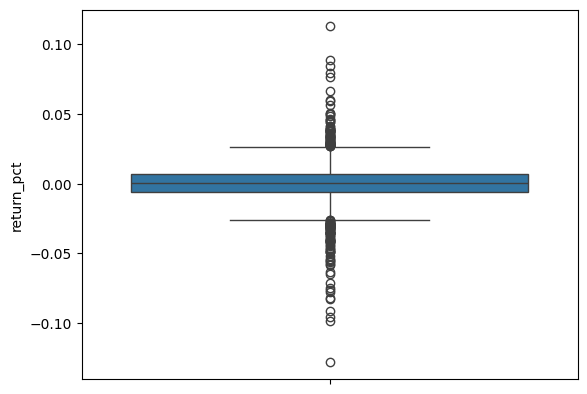

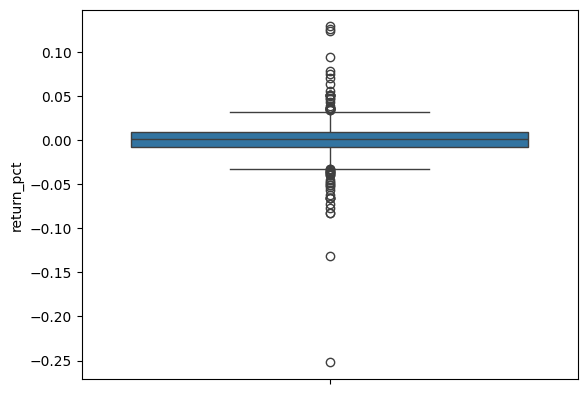

In [10]:
sns.boxplot(Y_train)
plt.show()
plt.figure()
sns.boxplot(Y_test)
plt.show()

In [11]:
from sklearn.linear_model import RidgeCV
# 1. Use the ORIGINAL feature set (X_train / X_test) — the one that
#    still has SMA/EMA/OBV/price-level collinearity in it.
#    This is the fair test of what Ridge is actually built to handle.
# ---------------------------------------------------------------

tss = TimeSeriesSplit(n_splits=5, gap=5)

# Candidate alphas to search over — wide range, log-spaced
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

pipe_ridge_full = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("model", RidgeCV(alphas=alphas, cv=tss))   # <-- time-aware CV for alpha search
])

# ---------------------------------------------------------------
# 2. Cross-validate the WHOLE pipeline (outer loop) on train data
#    — this tells you how stable/generalizable the pipeline is,
#    separate from the alpha search happening inside RidgeCV itself
# ---------------------------------------------------------------
cv_results = cross_validate(
    estimator=pipe_ridge_full, X=X_train, y=Y_train, cv=tss,
    scoring={"r2": "r2", "mae": "neg_mean_absolute_error"}
)

print("--- Cross-validation (train set only) ---")
print("R2  per fold:", cv_results["test_r2"])
print("MAE per fold:", -cv_results["test_mae"])
print("R2  mean:", cv_results["test_r2"].mean())
print("MAE mean:", -cv_results["test_mae"].mean())

# ---------------------------------------------------------------
# 3. Fit once on the full train set, evaluate once on the held-out
#    test set (touched only here, at the end)
# ---------------------------------------------------------------
pipe_ridge_full.fit(X_train, Y_train)
pred_ridge_full = pipe_ridge_full.predict(X_test)

print("\n--- Final test set (touched once) ---")
print("MAE:", mean_absolute_error(Y_test, pred_ridge_full))
print("R2 :", r2_score(Y_test, pred_ridge_full))

# ---------------------------------------------------------------
# 4. Which alpha did RidgeCV actually pick?
# ---------------------------------------------------------------
fitted_ridge = pipe_ridge_full.named_steps["model"]
print("\nBest alpha chosen:", fitted_ridge.alpha_)

--- Cross-validation (train set only) ---
R2  per fold: [-0.02880275  0.00819101 -0.00197171  0.00091409  0.00798909]
MAE per fold: [0.00801073 0.00974203 0.00747532 0.0122719  0.01122052]
R2  mean: -0.002736055361283474
MAE mean: 0.009744100034987846

--- Final test set (touched once) ---
MAE: 0.01750219255346186
R2 : -0.6184485380411793

Best alpha chosen: 1000.0


1. Now since beating the baseline was harder with noisy and weak signal data set i thought to move towards model selection which suprisingly served another proof for weak data signal and noise.
2. So i selected 3 models : Ridge because it push the high magnitude coefficients close to 0 and more robust to multicollinearlity than linear regression which is required in data set something like this i first check it on  pipeline 4 i.e. with pca so to see do it performs better if we reduce multicollinearity problem for it and only use if for regualirzation it performed bad so i gave raw data set with scaling and it performed better so i concluded that pca and its own robustness may cause overkill but it still couldn't beat baseline. 
4. Ridge also performed bad on mae and in r2 against feature removal + lr pipline say pipe5 which shows that features are too much weak in signals and noisy and patters are so weak that even handling multicollinearity and penalizing large coefficients do not perform better than simply removing them. 
3. Next i used lasso which gave me very huge shock so we evaluated it on differnt alphas like rdige shown in code sell and it as it's working (i.e push coefficients to literal 0 ) it pushed the all features except adjusted to 0 and selected only 1 feature out of 31 and dropped 30 which shocked that how much the features were noisy and weak signals than i expected since lasso peformed best i selected it for futhur process it is already hyper parameter tunned using traditional methods which evaluate on k folds instead of timesplit may make it less efficient so i choosed the alpha selected in our code cell.
4. I also used Random Forest too to see wheater the feature provide any good result in non linear relationship well low mi also indicate weak non linear and linear realtion but still testing on random forest was worth to satisfy this furthur and random forest also performed less than lasso that is why it is not selected instead of lasso.

In [12]:
# after getting predictions from both pipelines on X_test
errors_ridge = np.abs(Y_test - pred_ridge_full)
errors_removal_lr = np.abs(Y_test - pred_clean)

worst_days = Y_test.abs().sort_values(ascending=False).index[:3]
print("Ridge MAE excluding top 3 outlier days:", errors_ridge.drop(worst_days).mean())
print("Removal+LR MAE excluding top 3 outlier days:", errors_removal_lr.drop(worst_days).mean())

Ridge MAE excluding top 3 outlier days: 0.017126508834491114
Removal+LR MAE excluding top 3 outlier days: 0.01421053033681271


In [13]:
from sklearn.linear_model import LassoCV

tss = TimeSeriesSplit(n_splits=5, gap=5)

# Lasso alphas are typically much smaller than Ridge's — log-spaced, low range
alphas = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0]

pipe_lasso_full = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler(with_mean=True,with_std=True)),
    ("model", LassoCV(alphas=alphas, cv=tss, random_state=42, max_iter=100000))
])

# --- CV on train ---
cv_results = cross_validate(
    estimator=pipe_lasso_full, X=X_train, y=Y_train, cv=tss,
    scoring={"r2": "r2", "mae": "neg_mean_absolute_error"}
)
print("--- Cross-validation (train set only) ---")
print("R2  per fold:", cv_results["test_r2"])
print("MAE per fold:", -cv_results["test_mae"])
print("R2  mean:", cv_results["test_r2"].mean())
print("MAE mean:", -cv_results["test_mae"].mean())

# --- Fit once, test once ---
pipe_lasso_full.fit(X_train, Y_train)
pred_lasso_full = pipe_lasso_full.predict(X_test)

print("\n--- Final test set (touched once) ---")
print("MAE:", mean_absolute_error(Y_test, pred_lasso_full))
print("R2 :", r2_score(Y_test, pred_lasso_full))

fitted_lasso = pipe_lasso_full.named_steps["model"]
print("\nBest alpha chosen:", fitted_lasso.alpha_)

# --- The actually interesting part: which features survived ---
coef_series = pd.Series(fitted_lasso.coef_, index=X_train.columns)
kept = coef_series[coef_series != 0].sort_values(key=abs, ascending=False)
dropped = coef_series[coef_series == 0].index.tolist()

print(f"\nFeatures kept ({len(kept)}):")
print(kept)
print(f"\nFeatures dropped to zero ({len(dropped)}):")
print(dropped)
import joblib 
features = {}
for i in X.columns:
    features[i] = i

artifacts = {
    "features":features,
    "model":pipe_lasso_full
}
joblib.dump(artifacts,"pipeline_rasso.pkl")

--- Cross-validation (train set only) ---
R2  per fold: [-1.15942627e-02  2.34778671e-03 -1.36414139e-04 -8.66445832e-07
 -1.47517445e-03]
MAE per fold: [0.00791857 0.00976055 0.00736308 0.01235722 0.01124511]
R2  mean: -0.0021717861951715766
MAE mean: 0.00972890431527797

--- Final test set (touched once) ---
MAE: 0.0120978473628097
R2 : -0.007285868206884594

Best alpha chosen: 0.001

Features kept (1):
adjusted   -0.000131
dtype: float64

Features dropped to zero (30):
['close', 'high', 'low', 'open', 'volume', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_10', 'EMA_20', 'EMA_50', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_mid_20', 'BB_upper_20', 'BB_lower_20', 'BB_pctB_20', 'ATR', 'OBV', 'volatility_10', 'volatility_20', 'momentum_10', 'roc_10', 'momentum_20', 'roc_20', 'Value', 'wti_value', 'gold_price']


['pipeline_rasso.pkl']

In [14]:
pipe_rf_full = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=5,          # shallow — guards against overfitting on ~2700 rows
        min_samples_leaf=10,  # forces each leaf to average over enough points to be stable
        random_state=42,
        n_jobs=-1
    ))
])

cv_rf_full = cross_validate(
    estimator=pipe_rf_full, X=X_train, y=Y_train, cv=tss,
    scoring={"r2": "r2", "mae": "neg_mean_absolute_error"}
)
print("--- RF (full features) CV ---")
print("R2 mean:", cv_rf_full["test_r2"].mean())
print("MAE mean:", -cv_rf_full["test_mae"].mean())

pipe_rf_full.fit(X_train, Y_train)
pred_rf_full = pipe_rf_full.predict(X_test)
print("Test MAE:", mean_absolute_error(Y_test, pred_rf_full))
print("Test R2 :", r2_score(Y_test, pred_rf_full))

# ---------------------------------------------------------------
# Pipeline B — Random Forest on PCA-reduced features
# (scaling required here since PCA is distance-based)
# ---------------------------------------------------------------
pipe_rf_pca = Pipeline(steps=[
    ("preprocess",column4),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ))
])

cv_rf_pca = cross_validate(
    estimator=pipe_rf_pca, X=X_train, y=Y_train, cv=tss,
    scoring={"r2": "r2", "mae": "neg_mean_absolute_error"}
)
print("\n--- RF (PCA) CV ---")
print("R2 mean:", cv_rf_pca["test_r2"].mean())
print("MAE mean:", -cv_rf_pca["test_mae"].mean())

pipe_rf_pca.fit(X_train, Y_train)
pred_rf_pca = pipe_rf_pca.predict(X_test)
print("Test MAE:", mean_absolute_error(Y_test, pred_rf_pca))
print("Test R2 :", r2_score(Y_test, pred_rf_pca))

# ---------------------------------------------------------------
# The genuinely useful extra output for RF: feature importances
# (only meaningful for pipeline A — PCA components aren't interpretable)
# ---------------------------------------------------------------
fitted_rf = pipe_rf_full.named_steps["model"]
importances = pd.Series(fitted_rf.feature_importances_, index=X_train.columns)
print("\nTop 10 features by importance:")
print(importances.sort_values(ascending=False).head(10))



--- RF (full features) CV ---
R2 mean: -0.08096264017732184
MAE mean: 0.010284849208211483
Test MAE: 0.012968928835662188
Test R2 : -0.12501118610395512

--- RF (PCA) CV ---
R2 mean: -0.13631215544291125
MAE mean: 0.010800214359415023
Test MAE: 0.012935650241300776
Test R2 : -0.1087549656826885

Top 10 features by importance:
MACD_hist        0.111334
volume           0.088844
close            0.074575
adjusted         0.069257
volatility_10    0.066571
low              0.058425
Value            0.046797
high             0.040167
OBV              0.035233
volatility_20    0.033419
dtype: float64
